In [8]:
import os
import copy
import torch
from tqdm import tqdm
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid
import torchvision.transforms.functional as F
from torchvision.models import resnet18, ResNet18_Weights
from torchinfo import summary
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [9]:
print("Torch version: ", torch.__version__)
print("Numpy version: ", np.__version__)
print("Pandas version: ", pd.__version__)
print("Seaborn version: ", sns.__version__)
# print("TQDM version: ", tqdm.__version__)

Torch version:  2.13.0
Numpy version:  2.5.1
Pandas version:  3.0.3
Seaborn version:  0.13.2


In [10]:
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  device = torch.device("mps")
else:
  device = torch.device("cpu")
  
print(f"Running on device: {device}")

Running on device: mps


In [11]:
images = os.listdir("all_data")
print(f"Number of images: {len(images)}")

Number of images: 5676


## Visualizing the Data

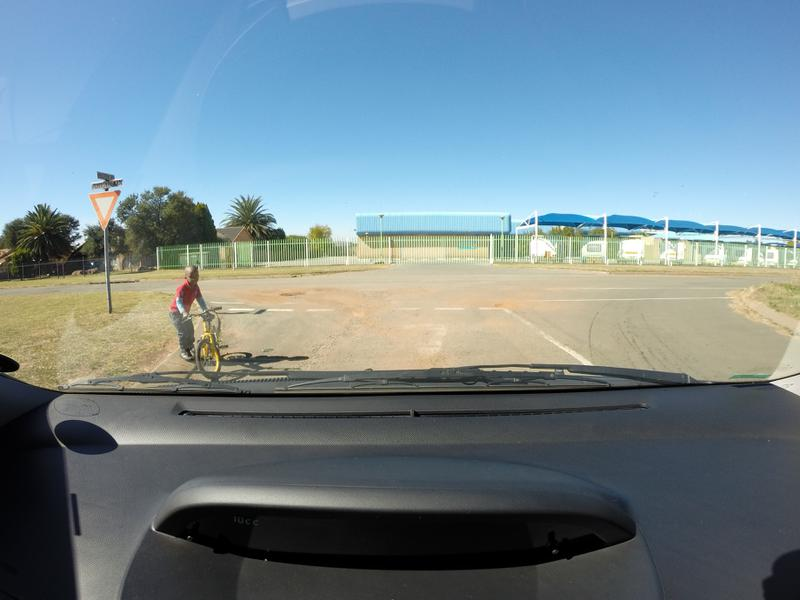

In [12]:
Image.open("all_data/aAAwuvUBxwBSvhR.JPG")

In [13]:
# Check if all the images have the same size
img_sizes = []
for img in tqdm(images):
  img_sizes.append(Image.open("all_data" + "/" + img).size)

img_sizes = torch.tensor(img_sizes)
img_sizes.unique()

100%|██████████| 5676/5676 [00:01<00:00, 4493.10it/s]


tensor([600, 800])

In [14]:
class ImageDataset(Dataset):
  def __init__(self, img_dir, csv_file, transforms=None):
    """
    Args:
      img_dir (string): Path to the image folder directory.
      csv_file (string): Path to the csv file containing image ids and labels.
      transforms (callable, optional): Optional transform to be applied to a sample.
    """
    # load the CSV into a pandas dataframe
    self.image_labels = pd.read_csv(csv_file)
    self.img_dir = img_dir
    self.transforms = transforms
    self.classes = self.image_labels.iloc[:, 1].unique()
    self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
  
  def __len__(self):
    return len(self.image_labels) 
  
  def __getitem__(self, row_index):
    # Get the image file name from CSV
    img_name = self.image_labels.iloc[row_index, 0]
    img_path = os.path.join(self.img_dir, img_name + ".JPG")
    
    # load the image using PIL
    image = Image.open(img_path)
    
    # get the corresponding image label
    label = self.image_labels.iloc[row_index, 1]
    
    if self.transforms:
      image = self.transforms(image)
    
    return image, label

In [15]:
import random

def show_samples(dataset, n=10):
  indices = random.sample(range(0, len(dataset)), n)
  samples = [dataset[i] for i in indices]
  imgs, labels = zip(*samples)
  grid = make_grid(list(imgs), nrow=5)
  plt.figure(figsize=(12, 6))
  plt.imshow(grid.permute(1, 2, 0))
  plt.axis("off")
  plt.show()

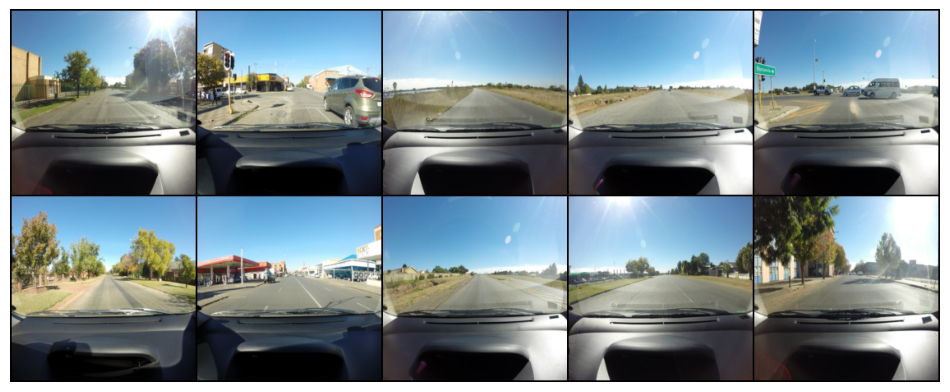

In [16]:
basic_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = ImageDataset(
  img_dir="all_data",
  csv_file="train_ids_labels.csv",
  transforms=basic_transforms
)

show_samples(dataset)

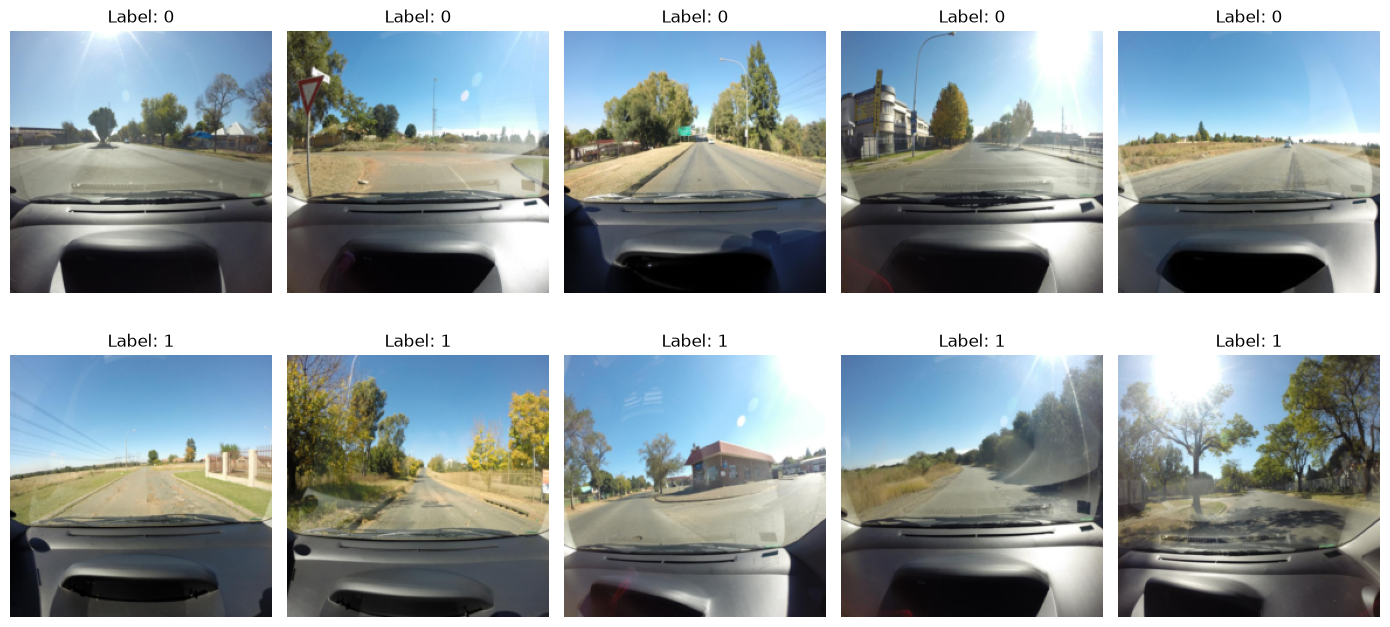

In [17]:
def show_balanced_samples(dataset, n_per_class=5, figsize=(14, 7)):
  negative_indices, positive_indices = [], []
  for i in range(len(dataset)):
    if isinstance(dataset, ImageDataset):
      label = dataset.image_labels.iloc[i, 1] 
    else:
      label = dataset.dataset.image_labels.iloc[i, 1]
    if label == 1:
      positive_indices.append(i)
    else:
      negative_indices.append(i)
      
  sampled_negatives = random.sample(negative_indices, n_per_class)
  sampled_positives = random.sample(positive_indices, n_per_class)
  selected_indices = sampled_negatives + sampled_positives
      
  fig, axes = plt.subplots(nrows=2, ncols=n_per_class, figsize=figsize)
  flat_axes = axes.flatten()
  for ax, idx in zip(flat_axes, selected_indices):
    img, label = dataset[idx]
    
    # img shape is [C, H, W], matplotlib expects [H, W, C]
    img = img.permute(1, 2, 0)
    
    ax.imshow(img)
    ax.set_title(f"Label: {label}")
    ax.axis("off")
  plt.tight_layout()
  plt.show()
  
show_balanced_samples(dataset)

## Train Dataset

In [18]:
batch_size = 32

## Validation dataset

## Modeling

In [19]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

In [20]:
# LR scheduler
# scheduler = StepLR(
#   optimizer,
#   step_size=4,
#   gamma=0.2
# )

# Early stopping
def early_stopping(validation_loss, best_val_loss, counter, patience=5):
  stop = False
  if validation_loss < best_val_loss:
    counter = 0
  else:
    counter += 1
  
  if counter >= patience:
    stop = True
    
  return counter, stop

# Checkpointing
def checkpointing(validation_loss, model, optimizer, save_path):
  torch.save(
    {
              "model_state_dict": model.state_dict(),
              "optimizer_state_dict": optimizer.state_dict(),
              "loss": validation_loss,
          },
          save_path,
  )
  print(f"Checkpoint saved with validation loss {validation_loss:.4f}")

In [21]:
def train_epoch(model, optimizer, loss_fn, data_loader, device="mps"):
  training_loss = 0.0
  model.train() # set model to traing mode
  
  for imgs, labels in tqdm(data_loader, desc="Training model", leave=False):
    optimizer.zero_grad() # for each batch, start with zero gradients
    imgs = imgs.to(device)
    # labels = labels.to(device)
    labels = labels.to(device).float().unsqueeze(1) # for BCEWithLogitsLoss, labels must be floats and have same shape as output
    # print(labels.unique())
    
    output = model(imgs) # forward pass
    loss = loss_fn(output, labels) # compute loss
    
    loss.backward() # backprop
    optimizer.step() # 
    
    training_loss += loss.data.item() * imgs.size(0)
    
  return training_loss / len(data_loader.dataset)

In [22]:
def score(model, loss_fn, data_loader, device="mps"):
  total_loss = 0
  total_correct = 0
  model.eval()
  
  with torch.no_grad():
    for imgs, labels in tqdm(data_loader, desc="Scoring", leave=False):
      imgs = imgs.to(device)
      labels = labels.to(device).float().unsqueeze(1)
      
      output = model(imgs)
      loss = loss_fn(output, labels)

      probs = torch.sigmoid(output)
      preds = (probs >= 0.5).float()

      correct = torch.eq(preds, labels)
      total_correct += correct.sum().item()
      
      total_loss += loss.data.item() * imgs.size(0) # compute total loss
      
  average_loss = total_loss / len(data_loader.dataset)
  accuracy = total_correct / len(data_loader.dataset)
  return average_loss, accuracy

In [23]:
def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="mps", scheduler=None, checkpoint_path=None, early_stopping=None):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    learning_rates = []

    best_val_loss = float("inf")
    early_stopping_counter = 0

    print("Model evaluation before start of training...")
    train_loss, train_accuracy = score(model, loss_fn, train_loader, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    validation_loss, validation_accuracy = score(model, loss_fn, val_loader, device)
    val_losses.append(validation_loss)
    val_accuracies.append(validation_accuracy)

    for epoch in range(1, epochs + 1):
        print("\n")
        print(f"Starting epoch {epoch}/{epochs}")

        train_epoch(model, optimizer, loss_fn, train_loader, device)

        train_loss, train_accuracy = score(model, loss_fn, train_loader, device)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        validation_loss, validation_accuracy = score(model, loss_fn, val_loader, device)
        val_losses.append(validation_loss)
        val_accuracies.append(validation_accuracy)

        print(f"Epoch: {epoch}")
        print(f"Training loss: {train_loss:.4f}")
        print(f"Training accuracy: {train_accuracy*100:.4f}%")
        print(f"Validation loss: {validation_loss:.4f}")
        print(f"Validation accuracy: {validation_accuracy*100:.4f}%")

        lr = optimizer.param_groups[0]["lr"]
        learning_rates.append(lr)

        if scheduler:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(validation_loss)
            else:
                scheduler.step()

        prev_best = best_val_loss
        
        improved = validation_loss < prev_best
        if checkpoint_path and improved:
            checkpointing(validation_loss, model, optimizer, checkpoint_path)

        if early_stopping:
            early_stopping_counter, stop = early_stopping(validation_loss, prev_best, early_stopping_counter)
            if stop:
                print(f"Early stopping triggered after {epoch} epochs")
                break

        if improved:
            best_val_loss = validation_loss

    return (
        learning_rates,
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies,
        epoch,
    )

In [24]:
def plot_training_results(train_results, figsize=(16, 4)):
    (
        learning_rates,
        train_losses,
        valid_losses,
        train_accuracies,
        valid_accuracies,
        epochs,
    ) = train_results

    num_epochs = min(
        len(train_losses),
        len(valid_losses),
        len(train_accuracies),
        len(valid_accuracies),
    )

    epoch_values = list(range(1, num_epochs + 1))

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=figsize)

    axes[0].plot(epoch_values, train_losses[:num_epochs], marker="o", label="Train")
    axes[0].plot(epoch_values, valid_losses[:num_epochs], marker="o", label="Validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epoch_values, train_accuracies[:num_epochs], marker="o", label="Train")
    axes[1].plot(epoch_values, valid_accuracies[:num_epochs], marker="o", label="Validation")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    lr_epoch_values = list(range(1, len(learning_rates) + 1))

    axes[2].plot(lr_epoch_values, learning_rates, marker="o", color="tab:green")
    axes[2].set_title("Learning Rate")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Learning Rate")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# plot_training_results(train_results, figsize=(16, 4))

## Implementing Transfer Learning

In [25]:
from torch.utils.data import Subset, random_split

labels_df = pd.read_csv("train_ids_labels.csv")  
all_labels = labels_df["Label"].values 
all_indices = np.arange(len(all_labels))
all_indices

array([   0,    1,    2, ..., 4023, 4024, 4025], shape=(4026,))

In [26]:

base_dataset = ImageDataset(
    img_dir="all_data",
    csv_file="train_ids_labels.csv",
    transforms=None
)

train_size = int(0.8 * len(base_dataset))
val_size = len(base_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

In [27]:
# Using imagenet's statistics for normalization to ensure we have similar input distribution as what ResNet was pretrained on
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transforms_resnet = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_transforms_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset_full_resnet = ImageDataset(
    img_dir="all_data",
    csv_file="train_ids_labels.csv",
    transforms=train_transforms_resnet,
)
val_dataset_full_resnet = ImageDataset(
    img_dir="all_data",
    csv_file="train_ids_labels.csv",
    transforms=val_transforms_resnet,
)
 
train_dataset_resnet = Subset(train_dataset_full_resnet, train_subset.indices)
val_dataset_resnet = Subset(val_dataset_full_resnet, val_subset.indices)
 
train_dataloader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle=True)
val_dataloader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle=False)

In [28]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
test_batch = next(iter(train_dataloader_resnet))[0]
batch_shape = test_batch.shape

summary(model, input_size=batch_shape)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 1000]                --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│

In [29]:
list(model.named_modules())[-1]

('fc', Linear(in_features=512, out_features=1000, bias=True))

In [30]:

def build_resnet18(freeze_backbone=True):
  model = resnet18(weights=ResNet18_Weights.DEFAULT)
  model.fc = nn.Linear(model.fc.in_features, 1)
  
  if freeze_backbone:
    for name, param in model.named_parameters():
      if not name.startswith('fc.'): # don't freeze the last layer
        param.requires_grad = False
        
  return model

In [31]:
k = 5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results, best_val_losses = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_indices, all_labels)):
    print(f"\n{'='*20} Fold {fold + 1}/{k} {'='*20}")

    # fresh datasets for this fold
    train_dataset_fold = Subset(
    ImageDataset(img_dir="all_data", csv_file="train_ids_labels.csv", transforms=train_transforms_resnet), train_idx
    )

    val_dataset_fold = Subset(
        ImageDataset(img_dir="all_data", csv_file="train_ids_labels.csv", transforms=val_transforms_resnet), val_idx
    )

    train_loader_fold = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
    val_loader_fold = DataLoader(val_dataset_fold, batch_size=batch_size, shuffle=False)

    # initialize fresh model/fold - each fold needs to start from the same pretrained starting point
    model_fold = build_resnet18(freeze_backbone=True)
    model_fold.to(device)
    loss_fn = nn.BCEWithLogitsLoss()

    # Phase 1: head only
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model_fold.parameters()), lr=1e-3
    )

    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    train(
        model_fold, optimizer, loss_fn,
        train_loader_fold, val_loader_fold,
        epochs=8, device=device, scheduler=scheduler,
        checkpoint_path=f"models/resnet_fold{fold}_phase1.pth",
        early_stopping=early_stopping,
    )
    
    # Phase 2: unfreeze, differential LR
    for param in model_fold.parameters():
        param.requires_grad = True
  
    optimizer = optim.AdamW([
        {"params": model_fold.fc.parameters(), "lr": 1e-4},
        {"params": (p for n, p in model_fold.named_parameters()
                        if not n.startswith("fc.")), "lr": 1e-5},
    ])

    checkpoint = torch.load(f"models/resnet_fold{fold}_phase1.pth", map_location=device)
    model_fold.load_state_dict(checkpoint["model_state_dict"])

    fold_history = train(
        model_fold, optimizer, loss_fn,
        train_loader_fold, val_loader_fold,
        epochs=20, device=device, scheduler=scheduler,
        checkpoint_path=f"models/resnet_fold{fold}_final.pth",
        early_stopping=early_stopping,
    )
    
    (
    learning_rates,
    train_losses,
    valid_losses,
    train_accuracies,
    valid_accuracies,
    epochs,
    ) = fold_history

    # record this fold's best validation metric
    best_val_losses.append(min(valid_losses))
    fold_results.append(fold_history)


==================== Fold 1/5 ====================
Model evaluation before start of training...




Starting epoch 1/8


Epoch: 1
Training loss: 0.5046
Training accuracy: 78.4161%
Validation loss: 0.5135
Validation accuracy: 76.1787%
Checkpoint saved with validation loss 0.5135


Starting epoch 2/8


Epoch: 2
Training loss: 0.4504
Training accuracy: 82.3292%
Validation loss: 0.4657
Validation accuracy: 80.3970%
Checkpoint saved with validation loss 0.4657


Starting epoch 3/8


Epoch: 3
Training loss: 0.4279
Training accuracy: 81.1180%
Validation loss: 0.4821
Validation accuracy: 74.6898%


Starting epoch 4/8


...

Epoch: 16
Training loss: 0.0285
Training accuracy: 99.4722%
Validation loss: 0.1458
Validation accuracy: 95.4037%


Starting epoch 17/20


Epoch: 17
Training loss: 0.0230
Training accuracy: 99.3170%
Validation loss: 0.1342
Validation accuracy: 95.4037%


Starting epoch 18/20


Epoch: 18
Training loss: 0.0251
Training accuracy: 99.2238%
Validation loss: 0.1335
Validation accuracy: 95.7764%


Starting epoch 19/20


Epoch: 19
Training loss: 0.0183
Training accuracy: 99.5343%
Validation loss: 0.1304
Validation accuracy: 95.5280%


Starting epoch 20/20


Epoch: 20
Training loss: 0.0163
Training accuracy: 99.5654%
Validation loss: 0.1398
Validation accuracy: 96.0248%
Early stopping triggered after 20 epochs


### Aggregate across folds

In [32]:
mean_val_loss = np.mean(best_val_losses)
std_val_loss = np.std(best_val_losses)

print(f"\nCV val loss: {mean_val_loss:.4f} +/- {std_val_loss:.4f}")
print(f"Per-fold: {[round(x, 4) for x in best_val_losses]}")


CV val loss: 0.0838 +/- 0.0211
Per-fold: [0.0894, 0.0712, 0.0642, 0.0715, 0.1225]


### Using the 5 fold models for final predictions


In [33]:
def predict_ensemble(model_paths, test_dataloader, device):
  all_probs = []
  for path in model_paths:
    m = build_resnet18(freeze_backbone=False)
    m.load_state_dict(torch.load(path, map_location=device)["model_state_dict"])
    m.to(device)
    m.eval()
    
    fold_probs = []
    with torch.no_grad():
      for images in test_dataloader:
        images = images.to(device)
        logits = m(images)
        probs = torch.sigmoid(logits).cpu().numpy()
        fold_probs.append(probs)
    all_probs.append(np.concatenate(fold_probs))
  
  # average across the folds
  return np.mean(all_probs, axis=0)

In [34]:
class ImageDatasetTest(Dataset):
  def __init__(self, img_dir, csv_file, transforms=None):
    """
    Args:
      img_dir (string): Path to the image folder directory.
      csv_file (string): Path to the csv file containing image ids only.
      transforms (callable, optional): Optional transform to be applied to a sample.
    """
    # load the CSV into a pandas dataframe
    self.image_ids = pd.read_csv(csv_file)
    self.img_dir = img_dir
    self.transforms = transforms
  
  def __len__(self):
    return len(self.image_ids) 
  
  def __getitem__(self, row_index):
    # Get the image file name from CSV
    image_id = self.image_ids.iloc[row_index, 0]
    img_path = os.path.join(self.img_dir, image_id + ".JPG")
    
    # load the image using PIL
    image = Image.open(img_path)
    
    if self.transforms:
      image = self.transforms(image)
    
    return image

In [35]:
test_transforms_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [36]:
test_dataset = ImageDatasetTest(
  img_dir="all_data",
  csv_file="test_ids_only.csv",
  transforms=test_transforms_resnet
)

In [37]:
test_loader = DataLoader(test_dataset, batch_size=batch_size)
test_ids = pd.read_csv("test_ids_only.csv")["Image_ID"]
len(test_dataset), test_ids.shape

(1650, (1650,))

In [41]:
model_paths = [f"models/resnet_fold{f}_final.pth" for f in range(k)]
predictions = predict_ensemble(model_paths, test_loader, device)

In [43]:

submission_df = pd.DataFrame({
  "Image_ID": test_ids,
  "Label": predictions.flatten()
})

In [44]:
submission_df.head()

,Image_ID,Label
0,nRhHxqLhDlJsiXc,0.248385
1,gbSntVovxgHQrmO,0.639807
2,nqOobGmvgEOiPms,0.000339
3,oIkPTooLcIbZKlF,0.999785
4,eSKxsTTJDQzkjgD,0.975920


In [45]:
submission_df.to_csv("submission.csv", index=False)
print(f"Submission saved! Rows: {len(submission_df)}")

Submission saved! Rows: 1650
